In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pathlib import Path

In [2]:
DATASET_PATH = Path() / "dataset"

# Zadanie 1

Celem zadania jest zastosowanie metody najmniejszych kwadratów do predykcji, czy nowotwór jest złośliwy (ang. malignant) czy łagodny (ang. benign). Nowotwory złośliwe i łagodne mają różne charakterystyki wzrostu. Istotne cechy to m. in. promień i tekstura. Charakterystyki te wyznaczane są poprzez diagnostykę obrazową i biopsje.

Nazwy kolumn znajdują się w pliku `breast-cancer.labels`. Pierwsza kolumna to identyfikator pacjenta `patient ID`. Dla każdego pacjenta wartość w kolumnie `Malignant/Benign` wskazuje klasę, tj. czy jego nowotwór jest złośliwy czy łagodny. Pozostałe 30 kolumn zawiera cechy, tj. charakterystyki nowotworu.

### a)
Otwórz zbiory `breast-cancer-train.dat` i `breast-cancer-validate.dat` używając funkcji `pd.io.parsers.read_csv` z biblioteki `pandas`.

In [3]:
df_labels = pd.read_csv(DATASET_PATH / r"breast-cancer.labels", header=None)
df_train = pd.read_csv(DATASET_PATH / r"breast-cancer-train.dat", names=df_labels[0])
df_validate = pd.read_csv(
    DATASET_PATH / r"breast-cancer-validate.dat", names=df_labels[0]
)

In [4]:
df_train

,patient ID,Malignant/Benign,radius (mean),texture (mean),perimeter (mean),area (mean),smoothness (mean),compactness (mean),concavity (mean),concave points (mean),...,radius (worst),texture (worst),perimeter (worst),area (worst),smoothness (worst),compactness (worst),concavity (worst),concave points (worst),symmetry (worst),fractal dimension (worst)
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.16220,0.66560,0.71190,0.26540,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.12380,0.18660,0.24160,0.18600,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.14440,0.42450,0.45040,0.24300,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.20980,0.86630,0.68690,0.25750,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.13740,0.20500,0.40000,0.16250,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,891923,B,13.77,13.27,88.06,582.7,0.09198,0.06221,0.01063,0.01917,...,14.67,16.93,94.17,661.1,0.11700,0.10720,0.03732,0.05802,0.2823,0.06794
296,891936,B,10.91,12.35,69.14,363.7,0.08518,0.04721,0.01236,0.01369,...,11.37,14.82,72.42,392.2,0.09312,0.07506,0.02884,0.03194,0.2143,0.06643
297,892189,M,11.76,18.14,75.00,431.1,0.09968,0.05914,0.02685,0.03515,...,13.36,23.39,85.10,553.6,0.11370,0.07974,0.06120,0.07160,0.1978,0.06915
298,892214,B,14.26,18.17,91.22,633.1,0.06576,0.05220,0.02475,0.01374,...,16.22,25.26,105.80,819.7,0.09445,0.21670,0.15650,0.07530,0.2636,0.07676


### b)
Stwórz histogram i wykres wybranej kolumny danych przy pomocy funkcji hist oraz plot.

In [5]:
field_name = "texture (mean)"

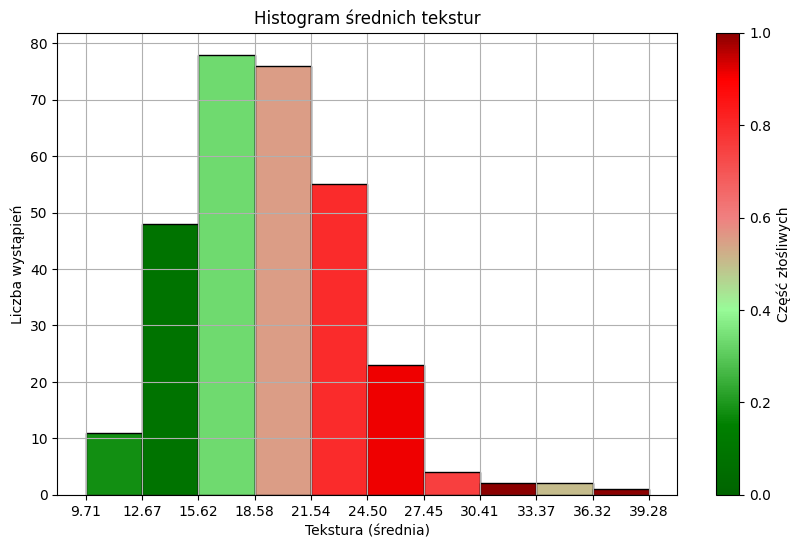

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(df_train[field_name], bins=10)
ax.set_xticks(bins)
ax.set_xlabel("Tekstura (średnia)")
ax.set_ylabel("Liczba wystąpień")
ax.set_title("Histogram średnich tekstur")
ax.grid(True)

norm = colors.Normalize(0, 1)
c = ["darkgreen", "green", "palegreen", "lightcoral", "red", "darkred"]
v = [0, 0.15, 0.4, 0.6, 0.9, 1.0]
cmap = LinearSegmentedColormap.from_list("rg", list(zip(v, c)), N=256)
for bin_s, bin_e, patch in zip(bins[:-1], bins[1:], patches):
    malignant_number = len(
        df_train[
            (df_train[field_name] >= bin_s)
            & (df_train[field_name] < bin_e)
            & (df_train["Malignant/Benign"] == "M")
        ]
    )
    benign_number = len(
        df_train[
            (df_train[field_name] >= bin_s)
            & (df_train[field_name] < bin_e)
            & (df_train["Malignant/Benign"] == "B")
        ]
    )
    if bin_e == bins[-1]:
        malignant_number += len(
            df_train[
                (df_train[field_name] == bin_e) & (df_train["Malignant/Benign"] == "M")
            ]
        )
        benign_number += len(
            df_train[
                (df_train[field_name] == bin_e) & (df_train["Malignant/Benign"] == "B")
            ]
        )
    percentage = (
        malignant_number / (malignant_number + benign_number)
        if (malignant_number + benign_number)
        else 0
    )
    color = cmap(norm(percentage))
    patch.set_facecolor(color)
    patch.set_edgecolor("black")

# Create color legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Część złośliwych")

plt.show()

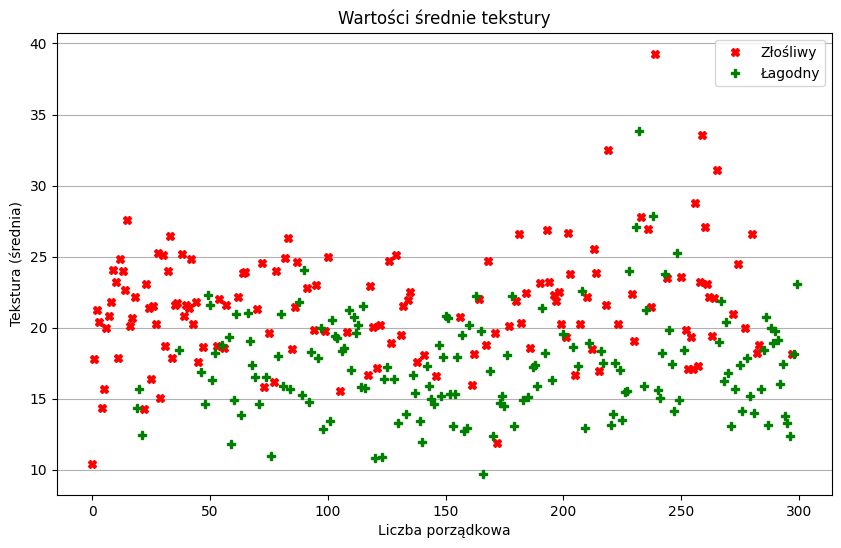

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_train[df_train["Malignant/Benign"] == "M"][field_name], "rX", label="Złośliwy"
)
plt.plot(
    df_train[df_train["Malignant/Benign"] == "B"][field_name], "gP", label="Łagodny"
)
plt.xlabel("Liczba porządkowa")
plt.ylabel("Tekstura (średnia)")
plt.title("Wartości średnie tekstury")
plt.grid(True, axis="y")
plt.legend()
plt.show()

### c)
Stwórz reprezentacje danych zawartych w obu zbiorach dla liniowej i kwadratowej metody najmniejszych kwadratów (łącznie 4 macierze). Dla reprezentacji kwadratowej użyj tylko podzbioru dostępnych danych, tj. danych z kolumn `radius (mean)`, `perimeter (mean)`, `area (mean)`, `symmetry (mean)`.

In [8]:
lin_matrix_train = df_train.iloc[:, 2:].values
lin_matrix_validate = df_validate.iloc[:, 2:].values

In [9]:
col_names = ["radius (mean)", "perimeter (mean)", "area (mean)", "symmetry (mean)"]
quad_matrix_train = np.hstack(
    [
        df_train[col_names].values,
        df_train[col_names].values ** 2,
        # https://carlostgameiro.medium.com/fast-pairwise-combinations-in-numpy-c29b977c33e2
        np.prod(
            df_train[col_names].values[
                :, np.triu_indices(df_train[col_names].values.shape[1], k=1)
            ],
            axis=1,
        ),
    ]
)
quad_matrix_validate = np.hstack(
    [
        df_validate[col_names].values,
        df_validate[col_names].values ** 2,
        np.prod(
            df_validate[col_names].values[
                :, np.triu_indices(df_validate[col_names].values.shape[1], k=1)
            ],
            axis=1,
        ),
    ]
)
# ["radius (mean)", "perimeter (mean)", "area (mean)", "symmetry (mean)",
# "radius (mean)"^2, "perimeter (mean)"^2, "area (mean)"^2, "symmetry (mean)"^2,
# "radius (mean)" * "perimeter (mean)", "radius (mean)" * "area (mean)",
# "radius (mean)" * "symmetry (mean)", "perimeter (mean)" * "area (mean)",
# "perimeter (mean)" * "symmetry (mean)", "area (mean)" * "symmetry (mean)"]

### d)
Stwórz wektor b dla obu zbiorów (tablicę numpy 1D-array o rozmiarze identycznym jak rozmiar kolumny `Malignant/Benign` odpowiedniego zbioru danych). Elementy wektora b to 1 jeśli nowotwór jest złośliwy, -1 w przeciwnym wypadku.

In [10]:
b_train = np.where(df_train["Malignant/Benign"] == "M", 1, -1)
b_validate = np.where(df_validate["Malignant/Benign"] == "M", 1, -1)

### e)
Znajdź wagi dla liniowej oraz kwadratowej reprezentacji najmniejszych kwadratów przy pomocy macierzy A zbudowanych na podstawie zbioru `breast-cancer-train.dat`. Potrzebny będzie także wektor b zbudowany na podstawie zbioru `breast-cancer-train.dat`.

In [11]:
w_lin_train = np.linalg.solve(
    lin_matrix_train.T @ lin_matrix_train, lin_matrix_train.T @ b_train
)
w_quad_train = np.linalg.solve(
    quad_matrix_train.T @ quad_matrix_train, quad_matrix_train.T @ b_train
)

### f)
Oblicz współczynniki uwarunkowania macierzy, cond($A^T A$), dla liniowej i kwadratowej metody najmniejszych kwadratów.

In [12]:
cond_lin_train = np.linalg.cond(lin_matrix_train.T @ lin_matrix_train)
cond_quad_train = np.linalg.cond(quad_matrix_train.T @ quad_matrix_train)

In [13]:
pd.DataFrame(
    {
        "cond_lin_train": cond_lin_train,
        "cond_quad_train": cond_quad_train,
    },
    index=[0],
).style.hide(axis="index").format("{:.2e}")

cond_lin_train,cond_quad_train
1.81e+12,9.06e+17


### g)
Sprawdź jak dobrze otrzymane wagi przewidują typ nowotworu (łagodny czy złośliwy). W tym celu pomnóż liniową reprezentację zbioru `breast-cancer-validate.dat` oraz wyliczony wektor wag dla reprezentacji liniowej. Następnie powtórz odpowiednie mnożenie dla reprezentacji kwadratowej. Zarówno dla reprezentacji liniowej jak i kwadratowej otrzymamy wektor $p$. Zakładamy, że jeśli $p[i] > 0$, to $i$-ta osoba prawdopodobnie) ma nowotwór złośliwy. Jeśli $p[i] \le 0$ to $i$-ta osoba prawdopodobnie) ma nowotwór łagodny.

Porównaj wektory $p$ dla reprezentacji liniowej i kwadratowej z wektorem $b$ (użyj reguł $p[i] > 0$ oraz $p[i] \le 0$).

Oblicz liczbę fałszywie dodatnich (ang. false-positives) oraz fałszywie ujemnych (ang. false-negatives) przypadków dla obu reprezentacji. Przypadek fałszywie dodatni zachodzi, kiedy model przewiduje nowotwór złośliwy, gdy w rzeczywistości nowotwór był łagodny. Przypadek fałszywie ujemny zachodzi, kiedy model przewiduje nowotwór łagodny, gdy w rzeczywistości nowotwór był złośliwy.

In [14]:
p_lin = lin_matrix_validate @ w_lin_train
p_quad = quad_matrix_validate @ w_quad_train

false_positive_lin = np.where((p_lin > 0) & (b_validate == -1), True, False)
false_negative_lin = np.where((p_lin <= 0) & (b_validate == 1), True, False)
false_positive_quad = np.where((p_quad > 0) & (b_validate == -1), True, False)
false_negative_quad = np.where((p_quad <= 0) & (b_validate == 1), True, False)

In [15]:
pd.DataFrame(
    {
        "total": b_validate.size,
        "false_positive_lin": false_positive_lin.sum(),
        "false_negative_lin": false_negative_lin.sum(),
        "false_positive_quad": false_positive_quad.sum(),
        "false_negative_quad": false_negative_quad.sum(),
    },
    index=[0],
).style.hide(axis="index")

total,false_positive_lin,false_negative_lin,false_positive_quad,false_negative_quad
260,6,2,15,5
